# Credit Default Risk — Econometric Analysis
### Logit vs Probit: Estimation, Interpretation & Model Evaluation

**Dataset:** UCI Default of Credit Card Clients (Taiwan, 2005)  
**Observations:** 30,000 | **Target:** Default next month (binary)

---
#### Analytical Pipeline
1. Data Loading & Cleaning  
2. Exploratory Data Analysis (EDA)  
3. Multicollinearity Check (VIF)  
4. Linear Probability Model (LPM) as baseline  
5. Logit Model — Estimation, Marginal Effects, Diagnostics  
6. Probit Model — Estimation, Marginal Effects, Diagnostics  
7. Side-by-Side Model Comparison  
8. Credit Scorecard Transformation (Logit)


## 1. Setup & Data Loading

In [1]:
# Install UCI repo helper (run once)
# !pip install ucimlrepo


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                              classification_report, brier_score_loss,
                              precision_score, recall_score, f1_score)
from sklearn.calibration import calibration_curve
from ucimlrepo import fetch_ucirepo

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
PALETTE = {'logit': '#2563EB', 'probit': '#DC2626', 'neutral': '#6B7280'}


In [4]:
# 1. Load the local CSV file
# Ensure the file is in the same folder as your script, or provide the full path
df = pd.read_csv('UCI_Credit_Card.csv')

# 2. Drop the 'ID' column if it exists (the UCI API version usually excludes it from features)
if 'ID' in df.columns:
    df = df.drop(columns=['ID'])

# 3. Canonical column names 
# Note: Local CSVs often use 'default.payment.next.month' as the target name
df.columns = [
    'LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6',
    'DEFAULT'
]

print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 2. Data Cleaning

The dataset contains undocumented category codes in EDUCATION (0, 5, 6) and MARRIAGE (0).  
Following the UCI data description, these are collapsed into the "other" category.


In [8]:
# ── Missing values ────────────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() else "None")

# ── Fix undocumented codes ─────────────────────────────────────────────────────
# EDUCATION: 1=grad, 2=university, 3=high school, 4=other; 0,5,6 → 4
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)

# MARRIAGE: 1=married, 2=single, 3=other; 0 → 3
df['MARRIAGE'] = df['MARRIAGE'].replace(0, 3)

print("EDUCATION value counts:", df['EDUCATION'].value_counts().to_dict())
print("MARRIAGE  value counts:", df['MARRIAGE'].value_counts().to_dict())
print(f"Default rate: {df['DEFAULT'].mean():.3f}  ({df['DEFAULT'].sum():,} defaults out of {len(df):,})")


Missing values per column:
None
EDUCATION value counts: {2: 14030, 1: 10585, 3: 4917, 4: 468}
MARRIAGE  value counts: {2: 15964, 1: 13659, 3: 377}
Default rate: 0.221  (6,636 defaults out of 30,000)


## 3. Exploratory Data Analysis

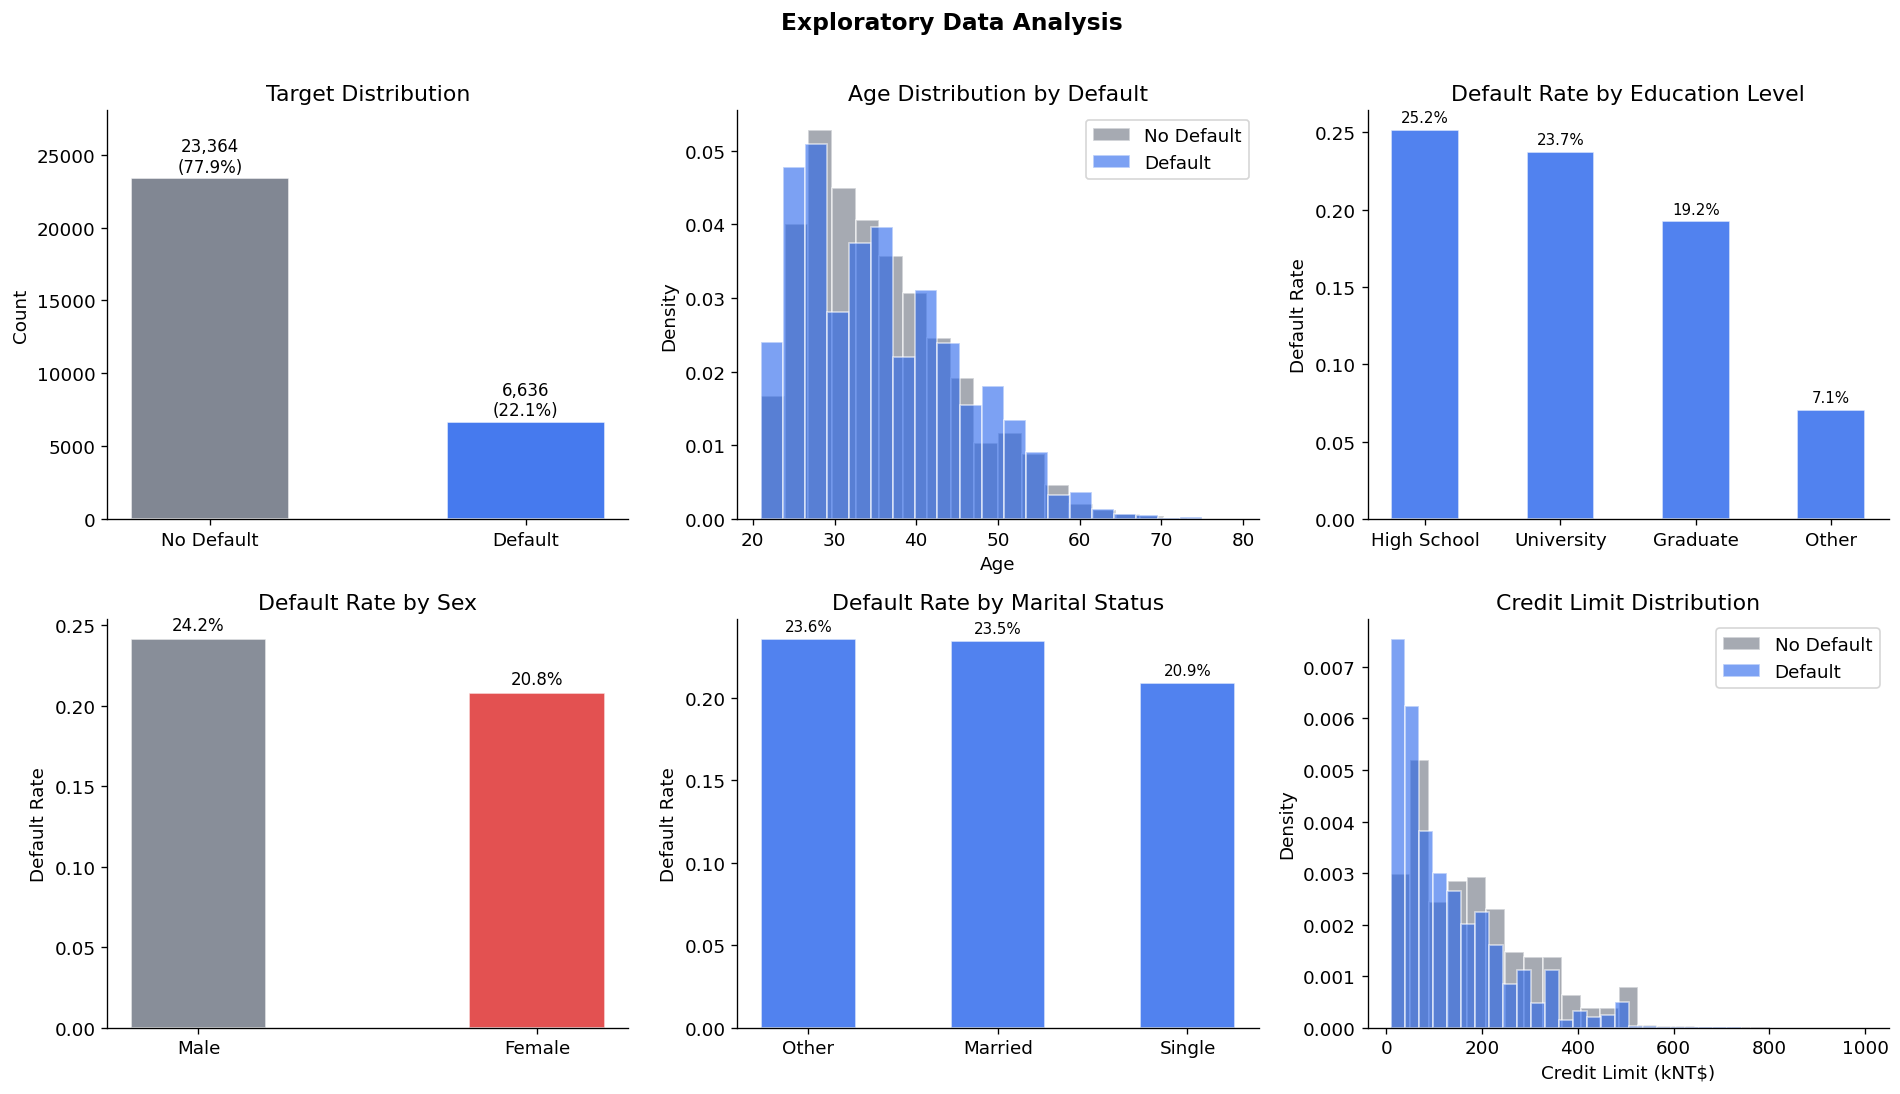

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold', y=1.01)

# ── 3a: Target distribution ──────────────────────────────────────────────────
ax = axes[0, 0]
counts = df['DEFAULT'].value_counts()
bars = ax.bar(['No Default', 'Default'], counts.values,
              color=[PALETTE['neutral'], PALETTE['logit']], alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    # FIXED: Added \n for line break within the string
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=10)
ax.set_title('Target Distribution')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)

# ── 3b: Age distribution by default ─────────────────────────────────────────
ax = axes[0, 1]
for val, label, color in [(0, 'No Default', PALETTE['neutral']), (1, 'Default', PALETTE['logit'])]:
    ax.hist(df.loc[df['DEFAULT']==val, 'AGE'], bins=20, alpha=0.6,
            label=label, color=color, edgecolor='white', density=True)
ax.set_title('Age Distribution by Default')
ax.set_xlabel('Age')
ax.set_ylabel('Density')
ax.legend()

# ── 3c: Default rate by Education ────────────────────────────────────────────
ax = axes[0, 2]
# Expanded map to handle undocumented UCI values
edu_map = {1:'Graduate', 2:'University', 3:'High School', 4:'Other', 5:'Other', 6:'Other', 0:'Other'}
# Group by mapping to ensure we don't have multiple "Other" bars
temp_df = df.copy()
temp_df['EDU_LABEL'] = temp_df['EDUCATION'].map(edu_map)
edu_rate = temp_df.groupby('EDU_LABEL')['DEFAULT'].mean().sort_values(ascending=False)

bars = ax.bar(edu_rate.index, edu_rate.values, color=PALETTE['logit'], alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(bars, edu_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)
ax.set_title('Default Rate by Education Level')
ax.set_ylabel('Default Rate')

# ── 3d: Default rate by Sex ──────────────────────────────────────────────────
ax = axes[1, 0]
sex_rate = df.groupby('SEX')['DEFAULT'].mean()
sex_labels = {1:'Male', 2:'Female'}
# Use list comprehension to get labels based on existing keys
bars = ax.bar([sex_labels[k] for k in sex_rate.index], sex_rate.values,
              color=[PALETTE['neutral'], PALETTE['probit']], alpha=0.8, edgecolor='white', width=0.4)
for bar, val in zip(bars, sex_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
ax.set_title('Default Rate by Sex')
ax.set_ylabel('Default Rate')

# ── 3e: Default rate by Marriage ─────────────────────────────────────────────
ax = axes[1, 1]
mar_map = {1:'Married', 2:'Single', 3:'Other', 0:'Other'}
temp_df['MAR_LABEL'] = temp_df['MARRIAGE'].map(mar_map)
mar_rate = temp_df.groupby('MAR_LABEL')['DEFAULT'].mean().sort_values(ascending=False)

bars = ax.bar(mar_rate.index, mar_rate.values, color=PALETTE['logit'], alpha=0.8, edgecolor='white', width=0.5)
for bar, val in zip(bars, mar_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.1%}', ha='center', va='bottom', fontsize=9)
ax.set_title('Default Rate by Marital Status')
ax.set_ylabel('Default Rate')

# ── 3f: Credit limit distribution ────────────────────────────────────────────
ax = axes[1, 2]
for val, label, color in [(0, 'No Default', PALETTE['neutral']), (1, 'Default', PALETTE['logit'])]:
    ax.hist(df.loc[df['DEFAULT']==val, 'LIMIT_BAL']/1000, bins=25, alpha=0.6,
            label=label, color=color, edgecolor='white', density=True)
ax.set_title('Credit Limit Distribution')
ax.set_xlabel('Credit Limit (kNT$)') # Cleaned up label
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Feature Engineering & Multicollinearity Check (VIF)

**Rule of thumb:** VIF > 10 signals problematic multicollinearity.  
The six monthly BILL_AMT variables tend to be highly correlated; we aggregate them into a single average.


In [13]:
# ── One-hot encode categoricals (drop_first avoids dummy trap) ───────────────
df_model = pd.get_dummies(df, columns=['SEX', 'EDUCATION', 'MARRIAGE'], drop_first=True)

# ── Aggregate bill statements → AVG_BILL ─────────────────────────────────────
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
df_model['AVG_BILL'] = df_model[bill_cols].mean(axis=1)
df_model.drop(columns=bill_cols, inplace=True)

# ── Build X matrix ────────────────────────────────────────────────────────────
X = df_model.drop(columns=['DEFAULT']).astype(float)
y = df_model['DEFAULT']
X_const = sm.add_constant(X)

# ── VIF table ────────────────────────────────────────────────────────────────
vif = pd.DataFrame({
    'Variable': X_const.columns,
    'VIF': [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
vif = vif[vif['Variable'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif.to_string(index=False))


   Variable      VIF
      PAY_5 4.704195
      PAY_4 4.275971
      PAY_3 3.637357
      PAY_6 3.205212
      PAY_2 3.152230
      PAY_0 1.919064
  LIMIT_BAL 1.573617
   AVG_BILL 1.461133
EDUCATION_3 1.408877
        AGE 1.385078
EDUCATION_2 1.365155
 MARRIAGE_2 1.329015
   PAY_AMT1 1.216845
   PAY_AMT3 1.195769
   PAY_AMT2 1.185204
   PAY_AMT4 1.147558
   PAY_AMT5 1.111350
   PAY_AMT6 1.108975
EDUCATION_4 1.034871
      SEX_2 1.024393
 MARRIAGE_3 1.023410


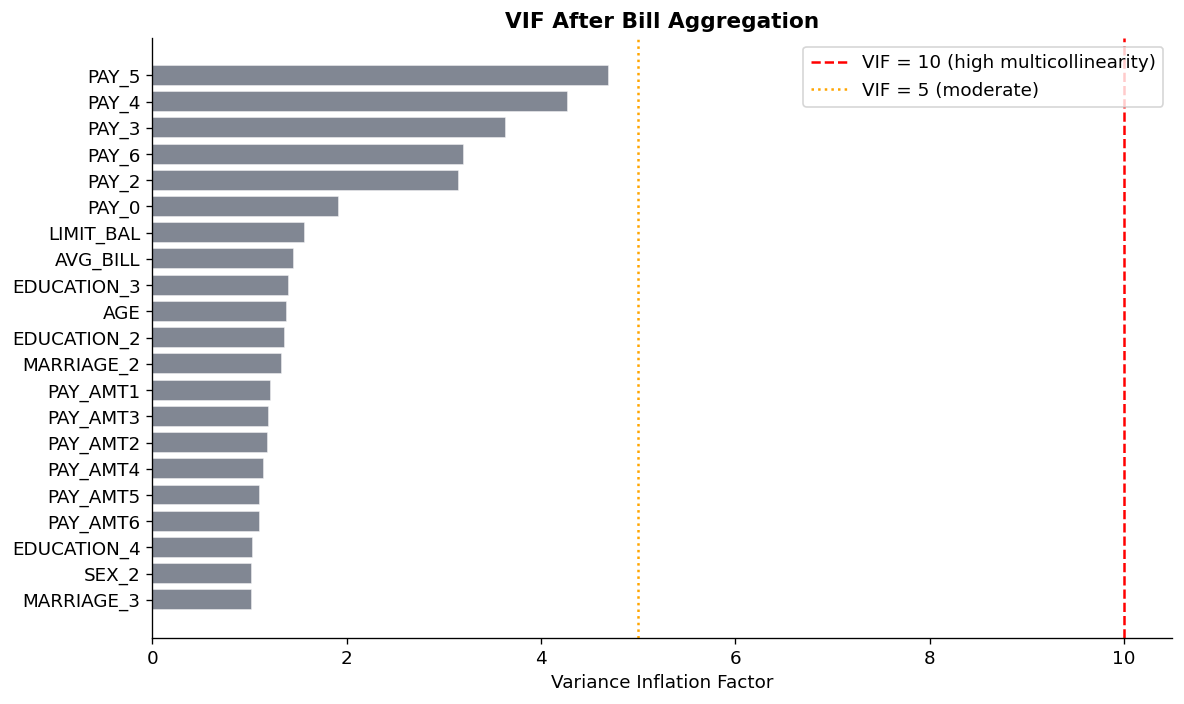

In [32]:
# ── VIF Bar Chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = [PALETTE['probit'] if v > 10 else PALETTE['logit'] if v > 5 else PALETTE['neutral']
          for v in vif['VIF']]
bars = ax.barh(vif['Variable'], vif['VIF'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(x=10, color='red', linestyle='--', linewidth=1.5, label='VIF = 10 (high multicollinearity)')
ax.axvline(x=5,  color='orange', linestyle=':', linewidth=1.5, label='VIF = 5 (moderate)')
ax.set_xlabel('Variance Inflation Factor')
ax.set_title('VIF After Bill Aggregation', fontsize=13, fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('vif_chart.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Linear Probability Model (LPM) — Baseline

The LPM is estimated first as a **benchmark**. It is known to be misspecified for binary outcomes 
(predicted probabilities can fall outside [0,1], errors are heteroskedastic by construction).  
We use HC3 robust standard errors and confirm misspecification with the Ramsey RESET test.


In [18]:
lpm = sm.OLS(y, X_const).fit(cov_type='HC3')
print(lpm.summary())


                            OLS Regression Results                            
Dep. Variable:                DEFAULT   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     150.6
Date:                Fri, 10 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:23:36   Log-Likelihood:                -14208.
No. Observations:               30000   AIC:                         2.846e+04
Df Residuals:                   29978   BIC:                         2.864e+04
Df Model:                          21                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2699      0.013     20.087      

In [19]:
reset = linear_reset(lpm, power=2, use_f=True)
print(reset)


<F test: F=419.7772517540639, p=1.1783522336234768e-92, df_denom=3e+04, df_num=1>


> **RESET Test Interpretation:** Rejection of H₀ (p < 0.001) means the LPM functional form  
> is misspecified — nonlinear models (Logit / Probit) are warranted.  
> The large condition number also reflects scale differences (not pure multicollinearity).


Out-of-[0,1] predictions: 2,312  (7.7% of sample)


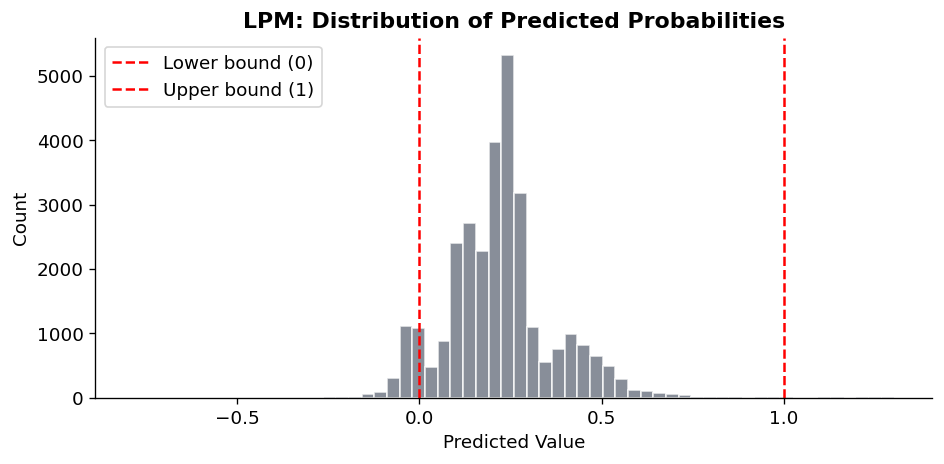

In [33]:
# ── LPM: Check for out-of-bound predictions ──────────────────────────────────
lpm_preds = lpm.predict(X_const)
out_of_bounds = ((lpm_preds < 0) | (lpm_preds > 1)).sum()
print(f"Out-of-[0,1] predictions: {out_of_bounds:,}  ({out_of_bounds/len(lpm_preds):.1%} of sample)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lpm_preds, bins=60, color=PALETTE['neutral'], alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Lower bound (0)')
ax.axvline(1, color='red', linestyle='--', linewidth=1.5, label='Upper bound (1)')
ax.set_title('LPM: Distribution of Predicted Probabilities', fontweight='bold')
ax.set_xlabel('Predicted Value')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('lpm_pred_dist.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Logit Model

### 6.1 Estimation

In [22]:
logit_result = sm.Logit(y, X_const).fit(maxiter=200)
print(logit_result.summary())


Optimization terminated successfully.
         Current function value: 0.464623
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                          Logit   Df Residuals:                    29978
Method:                           MLE   Df Model:                           21
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.1207
Time:                        10:24:23   Log-Likelihood:                -13939.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.0042      0.086    -11.621      0.000      -1.174      -0.835
LIMIT_BAL   -7.598e-07   1

In [23]:
# ── Odds Ratios ──────────────────────────────────────────────────────────────
odds_df = pd.DataFrame({
    'Coefficient': logit_result.params,
    'Odds Ratio': np.exp(logit_result.params),
    '95% CI Lower': np.exp(logit_result.conf_int()[0]),
    '95% CI Upper': np.exp(logit_result.conf_int()[1])
}).drop(index='const')
print(odds_df.round(4).to_string())


             Coefficient  Odds Ratio  95% CI Lower  95% CI Upper
LIMIT_BAL        -0.0000      1.0000        1.0000        1.0000
AGE               0.0057      1.0057        1.0021        1.0094
PAY_0             0.5818      1.7893        1.7281        1.8527
PAY_2             0.0697      1.0722        1.0307        1.1155
PAY_3             0.0772      1.0803        1.0335        1.1292
PAY_4             0.0264      1.0268        0.9777        1.0783
PAY_5             0.0386      1.0394        0.9862        1.0954
PAY_6             0.0158      1.0160        0.9732        1.0606
PAY_AMT1         -0.0000      1.0000        1.0000        1.0000
PAY_AMT2         -0.0000      1.0000        1.0000        1.0000
PAY_AMT3         -0.0000      1.0000        1.0000        1.0000
PAY_AMT4         -0.0000      1.0000        1.0000        1.0000
PAY_AMT5         -0.0000      1.0000        1.0000        1.0000
PAY_AMT6         -0.0000      1.0000        1.0000        1.0000
SEX_2            -0.1071 

### 6.2 Marginal Effects (Average Marginal Effects)

In [24]:
me_logit = logit_result.get_margeff(at='overall')
print(me_logit.summary())


        Logit Marginal Effects       
Dep. Variable:                DEFAULT
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
LIMIT_BAL   -1.133e-07   2.34e-08     -4.834      0.000   -1.59e-07   -6.74e-08
AGE             0.0009      0.000      3.073      0.002       0.000       0.001
PAY_0           0.0868      0.003     34.652      0.000       0.082       0.092
PAY_2           0.0104      0.003      3.461      0.001       0.005       0.016
PAY_3           0.0115      0.003      3.421      0.001       0.005       0.018
PAY_4           0.0039      0.004      1.058      0.290      -0.003       0.011
PAY_5           0.0058      0.004      1.442      0.149      -0.002       0.014
PAY_6           0.0024      0.003      0.722      0.470      -0.004       0.009
PAY_AMT1    -1.625e-06   3.18e-07     -5.113    

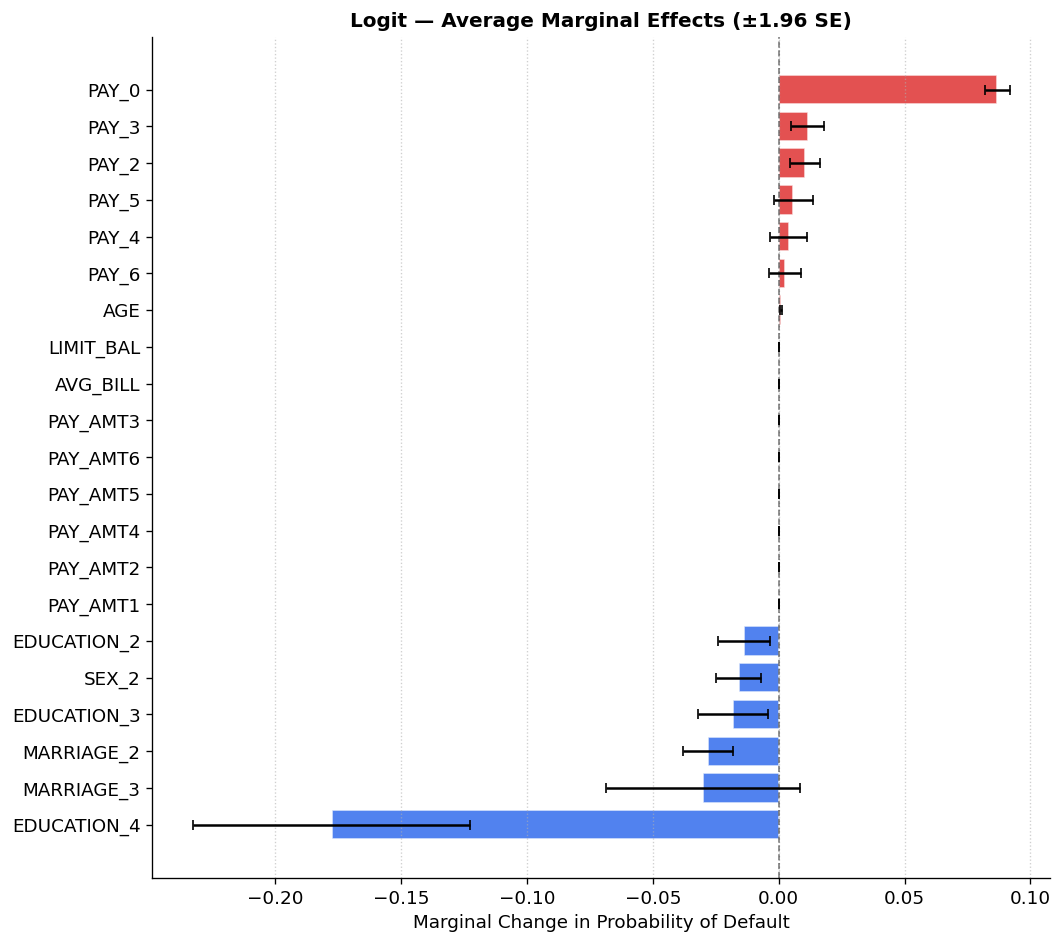

In [34]:
# ── Marginal Effects Plot ─────────────────────────────────────────────────────
# Use the summary_frame() to safely get indices, effects, and standard errors
me_summary = me_logit.summary_frame()

me_df = pd.DataFrame({
    'Variable': me_summary.index,
    'ME': me_summary['dy/dx'],
    'SE': me_summary['Std. Err.']
}).sort_values('ME')

fig, ax = plt.subplots(figsize=(9, 8)) # Increased height for many variables

# Use the palette defined previously
colors = [PALETTE['probit'] if v > 0 else PALETTE['logit'] for v in me_df['ME']]

# Horizontal bar plot with error bars
ax.barh(me_df['Variable'], me_df['ME'], 
        xerr=1.96 * me_df['SE'],
        color=colors, 
        alpha=0.8, 
        edgecolor='white', 
        capsize=3)

# Add a vertical line at 0 for reference
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Logit — Average Marginal Effects (±1.96 SE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Marginal Change in Probability of Default')
ax.grid(axis='x', linestyle=':', alpha=0.6) # Added grid for easier reading

plt.tight_layout()
plt.savefig('logit_me.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Model Diagnostics

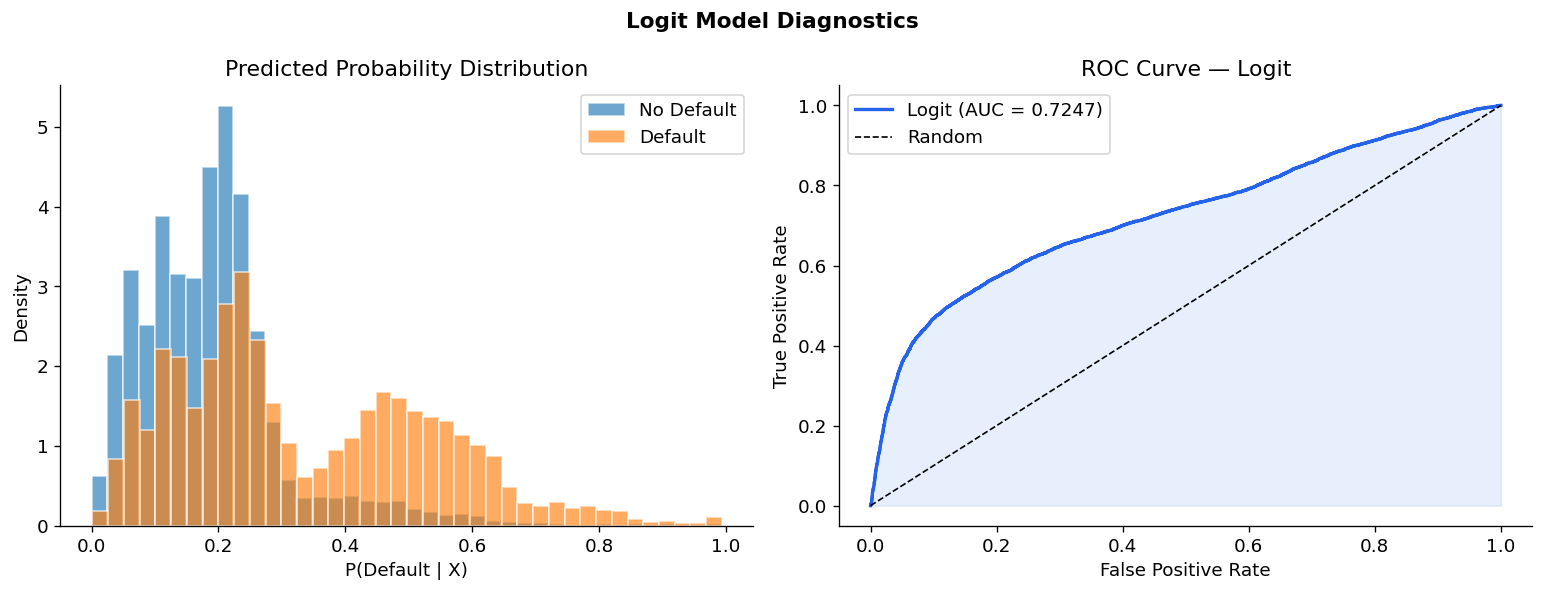

Logit AUC: 0.7247


In [31]:
# ── Predicted probability distribution ───────────────────────────────────────
df_model['prob_logit'] = logit_result.predict(X_const)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Predicted probability histogram by actual default
for val, label in [(0, 'No Default'), (1, 'Default')]:
    axes[0].hist(df_model.loc[df_model['DEFAULT']==val, 'prob_logit'],
                 bins=40, alpha=0.65, density=True,
                 label=label, edgecolor='white')
axes[0].set_title('Predicted Probability Distribution')
axes[0].set_xlabel('P(Default | X)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: ROC curve
fpr_l, tpr_l, thr_l = roc_curve(y, df_model['prob_logit'])
auc_l = roc_auc_score(y, df_model['prob_logit'])
axes[1].plot(fpr_l, tpr_l, color=PALETTE['logit'], lw=2, label=f'Logit (AUC = {auc_l:.4f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random')
axes[1].fill_between(fpr_l, tpr_l, alpha=0.1, color=PALETTE['logit'])
axes[1].set_title('ROC Curve — Logit')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.suptitle('Logit Model Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('logit_diag.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Logit AUC: {auc_l:.4f}")


In [29]:
# ── Youden optimal threshold ─────────────────────────────────────────────────
J_l = tpr_l - fpr_l
best_thr_l = thr_l[np.argmax(J_l)]
print(f"Optimal threshold (Youden J): {best_thr_l:.4f}")

df_model['pred_logit'] = (df_model['prob_logit'] > best_thr_l).astype(int)

print("Classification Report (Logit):")
print(classification_report(y, df_model['pred_logit']))


Optimal threshold (Youden J): 0.2661
Classification Report (Logit):
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     23364
           1       0.50      0.52      0.51      6636

    accuracy                           0.78     30000
   macro avg       0.68      0.69      0.69     30000
weighted avg       0.78      0.78      0.78     30000



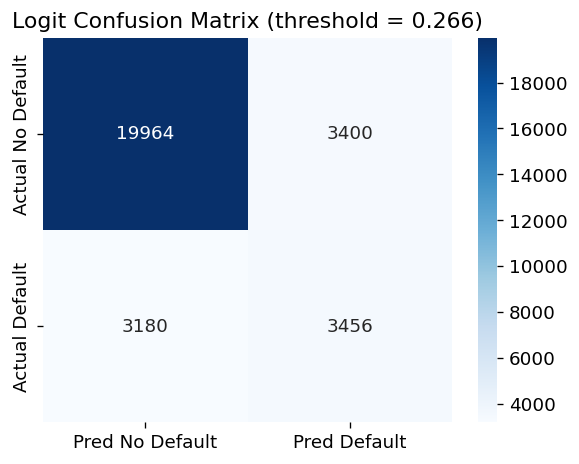

In [35]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
cm_l = confusion_matrix(y, df_model['pred_logit'])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_l, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No Default', 'Pred Default'],
            yticklabels=['Actual No Default', 'Actual Default'], ax=ax)
ax.set_title(f'Logit Confusion Matrix (threshold = {best_thr_l:.3f})')
plt.tight_layout()
plt.savefig('logit_cm.png', dpi=150, bbox_inches='tight')
plt.show()


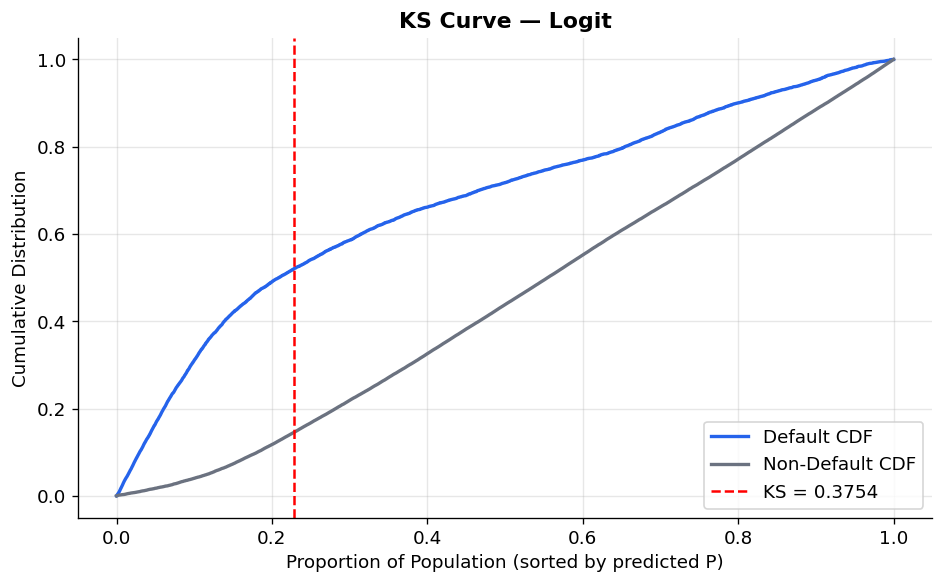

KS Statistic (Logit): 0.3754


In [36]:
# ── KS Curve ─────────────────────────────────────────────────────────────────
def ks_curve(probs, actuals, title, color, save_path):
    ks_df = pd.DataFrame({'prob': probs, 'actual': actuals})
    ks_df = ks_df.sort_values('prob', ascending=False).reset_index(drop=True)
    ks_df['cum_default']     = np.cumsum(ks_df['actual']) / ks_df['actual'].sum()
    ks_df['cum_non_default'] = np.cumsum(1-ks_df['actual']) / (1-ks_df['actual']).sum()
    ks_df['ks'] = ks_df['cum_default'] - ks_df['cum_non_default']
    ks_stat = ks_df['ks'].max()
    ks_idx  = ks_df['ks'].idxmax()
    x = np.arange(1, len(ks_df)+1) / len(ks_df)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, ks_df['cum_default'],     label='Default CDF',     color=color, lw=2)
    ax.plot(x, ks_df['cum_non_default'], label='Non-Default CDF', color=PALETTE['neutral'], lw=2)
    ax.axvline(ks_idx/len(ks_df), color='red', linestyle='--', label=f'KS = {ks_stat:.4f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Proportion of Population (sorted by predicted P)')
    ax.set_ylabel('Cumulative Distribution')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return ks_stat

ks_logit = ks_curve(df_model['prob_logit'], y,
                    'KS Curve — Logit', PALETTE['logit'],
                    'logit_ks.png')
print(f"KS Statistic (Logit): {ks_logit:.4f}")


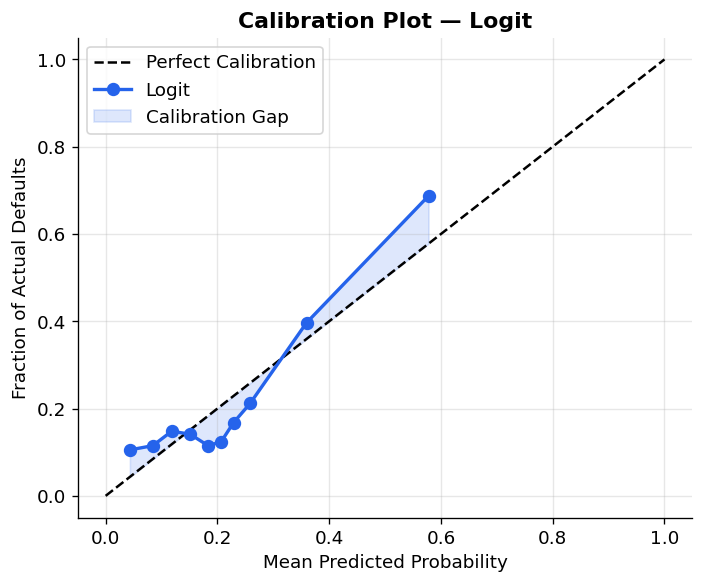

Brier Score (Logit): 0.1447


In [37]:
# ── Calibration Plot ─────────────────────────────────────────────────────────
def calibration_plot(probs, actuals, model_name, color, save_path):
    fop, mpv = calibration_curve(actuals, probs, n_bins=10, strategy='quantile')
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect Calibration')
    ax.plot(mpv, fop, marker='o', color=color, lw=2, ms=7, label=model_name)
    ax.fill_between(mpv, fop, mpv, alpha=0.15, color=color, label='Calibration Gap')
    ax.set_title(f'Calibration Plot — {model_name}', fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Actual Defaults')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

calibration_plot(df_model['prob_logit'], y,
                 'Logit', PALETTE['logit'],
                 'logit_calib.png')

brier_l = brier_score_loss(y, df_model['prob_logit'])
print(f"Brier Score (Logit): {brier_l:.4f}")


## 7. Probit Model

### 7.1 Estimation

In [38]:
probit_result = sm.Probit(y, X_const).fit(maxiter=200)
print(probit_result.summary())


Optimization terminated successfully.
         Current function value: 0.467964
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:                DEFAULT   No. Observations:                30000
Model:                         Probit   Df Residuals:                    29978
Method:                           MLE   Df Model:                           21
Date:                Fri, 10 Apr 2026   Pseudo R-squ.:                  0.1144
Time:                        10:32:13   Log-Likelihood:                -14039.
converged:                       True   LL-Null:                       -15853.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.6192      0.049    -12.590      0.000      -0.716      -0.523
LIMIT_BAL   -4.095e-07   8

### 7.2 Marginal Effects

In [39]:
me_probit = probit_result.get_margeff(at='overall')
print(me_probit.summary())


       Probit Marginal Effects       
Dep. Variable:                DEFAULT
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
LIMIT_BAL   -1.084e-07    2.3e-08     -4.713      0.000   -1.54e-07   -6.33e-08
AGE             0.0009      0.000      3.294      0.001       0.000       0.001
PAY_0           0.0827      0.003     32.732      0.000       0.078       0.088
PAY_2           0.0116      0.003      3.768      0.000       0.006       0.018
PAY_3           0.0109      0.003      3.223      0.001       0.004       0.018
PAY_4           0.0032      0.004      0.859      0.390      -0.004       0.011
PAY_5           0.0060      0.004      1.474      0.140      -0.002       0.014
PAY_6           0.0018      0.003      0.552      0.581      -0.005       0.008
PAY_AMT1     -1.32e-06   2.41e-07     -5.466    

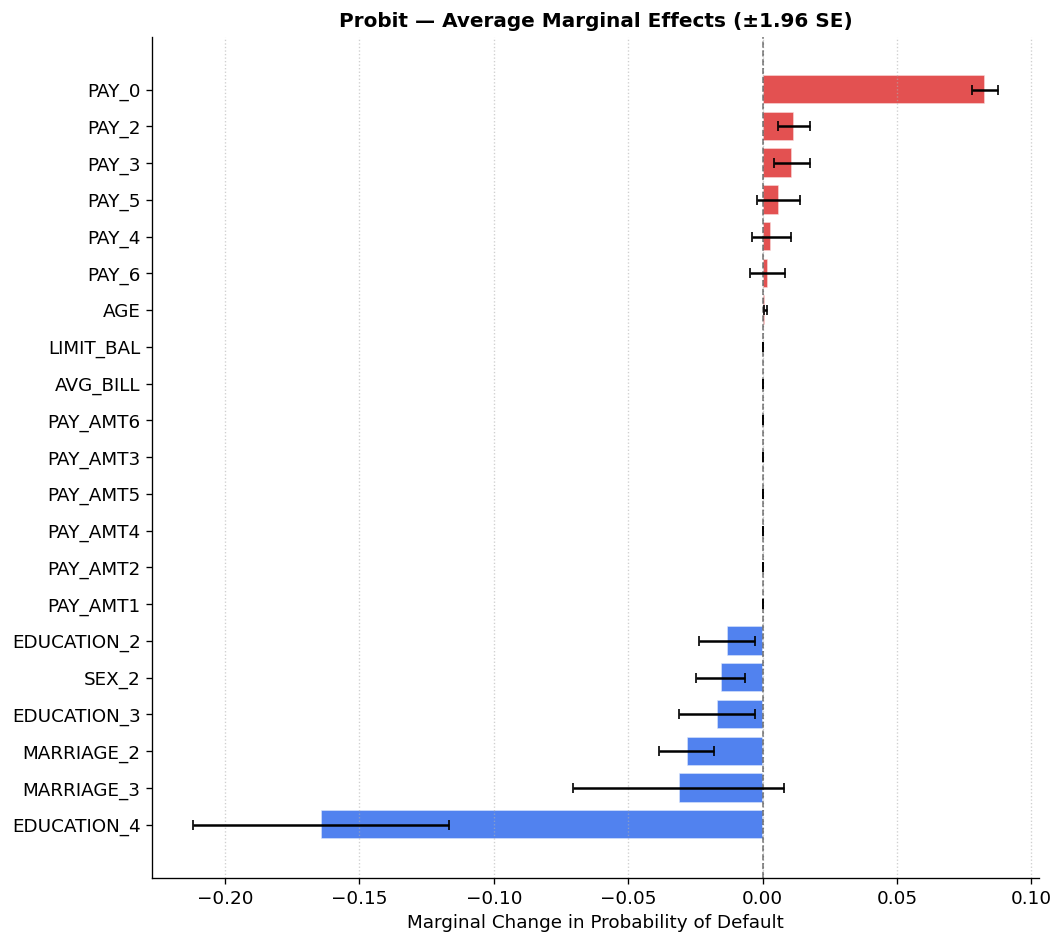

In [41]:
# ── Marginal Effects Plot ─────────────────────────────────────────────────────
# Using summary_frame() is the most reliable way to get index, effects, and SEs
me_summary_p = me_probit.summary_frame()

me_df_p = pd.DataFrame({
    'Variable': me_summary_p.index,
    'ME': me_summary_p['dy/dx'],
    'SE': me_summary_p['Std. Err.']
}).sort_values('ME')

fig, ax = plt.subplots(figsize=(9, 8)) # Increased height slightly for readability

# Applying the colors based on direction of the effect
colors_p = [PALETTE['probit'] if v > 0 else PALETTE['logit'] for v in me_df_p['ME']]

# Horizontal bar plot with 95% Confidence Interval error bars
ax.barh(me_df_p['Variable'], me_df_p['ME'], 
        xerr=1.96 * me_df_p['SE'],
        color=colors_p, 
        alpha=0.8, 
        edgecolor='white', 
        capsize=3)

# Reference line at 0 - variables whose error bars cross this are not statistically significant
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Probit — Average Marginal Effects (±1.96 SE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Marginal Change in Probability of Default')
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()

# Fixed: Saving to local directory to avoid FileNotFoundError
plt.savefig('probit_me.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Model Diagnostics

In [42]:
df_model['prob_probit'] = probit_result.predict(X_const)

# ROC
fpr_p, tpr_p, thr_p = roc_curve(y, df_model['prob_probit'])
auc_p = roc_auc_score(y, df_model['prob_probit'])

J_p = tpr_p - fpr_p
best_thr_p = thr_p[np.argmax(J_p)]

df_model['pred_probit'] = (df_model['prob_probit'] > best_thr_p).astype(int)
print(f"Probit AUC: {auc_p:.4f} | Optimal threshold: {best_thr_p:.4f}")
print("Classification Report (Probit):")
print(classification_report(y, df_model['pred_probit']))


Probit AUC: 0.7239 | Optimal threshold: 0.2696
Classification Report (Probit):
              precision    recall  f1-score   support

           0       0.86      0.85      0.86     23364
           1       0.50      0.52      0.51      6636

    accuracy                           0.78     30000
   macro avg       0.68      0.69      0.68     30000
weighted avg       0.78      0.78      0.78     30000



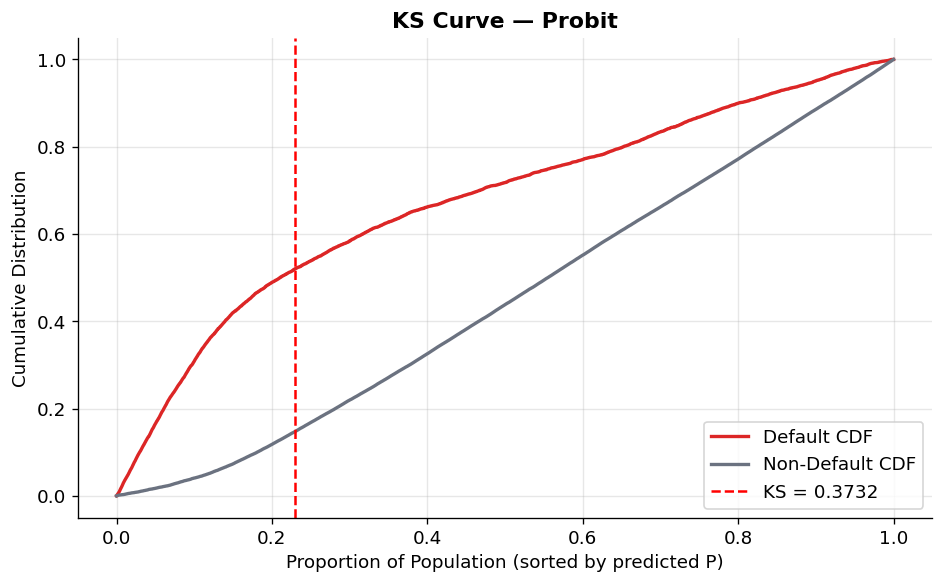

KS Statistic (Probit): 0.3732


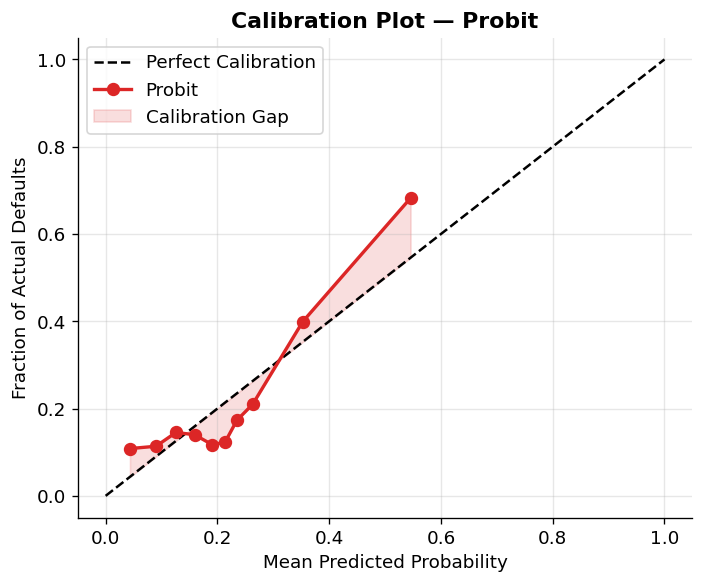

Brier Score (Probit): 0.1461


In [44]:
ks_probit = ks_curve(df_model['prob_probit'], y,
                     'KS Curve — Probit', PALETTE['probit'],
                     'probit_ks.png')
print(f"KS Statistic (Probit): {ks_probit:.4f}")

calibration_plot(df_model['prob_probit'], y,
                 'Probit', PALETTE['probit'],
                 'probit_calib.png')

brier_p = brier_score_loss(y, df_model['prob_probit'])
print(f"Brier Score (Probit): {brier_p:.4f}")


## 8. Logit vs Probit — Head-to-Head Comparison

This section presents all comparative diagnostics in a single view.


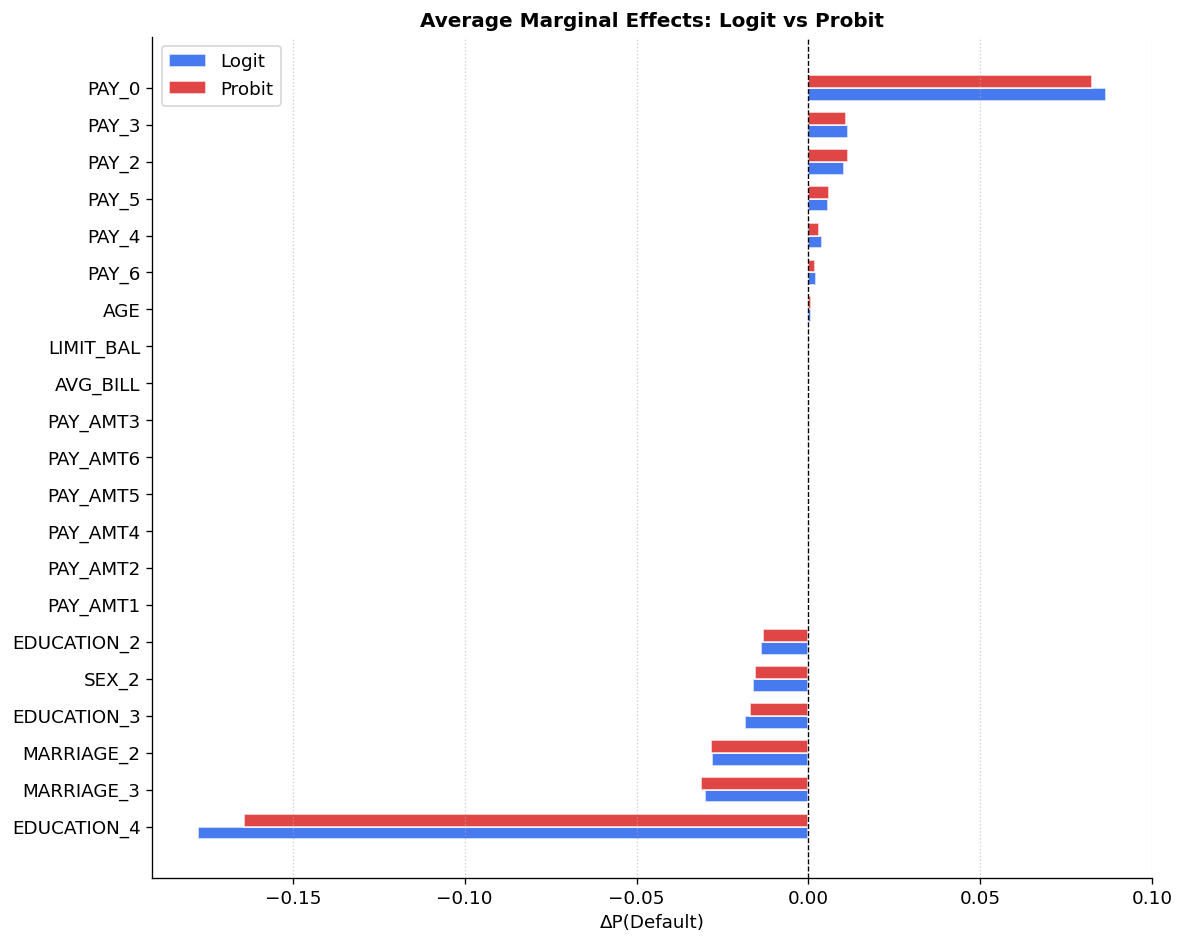

In [47]:
# ── Marginal Effects Comparison ───────────────────────────────────────────────
# 1. Safely extract data using summary_frame() to ensure indices match
df_logit = me_logit.summary_frame()
df_probit = me_probit.summary_frame()

# 2. Create comparison dataframe
# We join them to ensure variables align even if one model dropped a feature
me_compare = pd.DataFrame({
    'Logit ME':  df_logit['dy/dx'],
    'Probit ME': df_probit['dy/dx']
}).sort_values('Logit ME')

# 3. Plotting
# ── Marginal Effects Comparison ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
x_pos = np.arange(len(me_compare))
w = 0.35 # This now represents the 'thickness' of the horizontal bars

# Change 'width' to 'height'
ax.barh(x_pos - w/2, me_compare['Logit ME'],  height=w, label='Logit',  
        color=PALETTE['logit'],  alpha=0.85, edgecolor='white')

ax.barh(x_pos + w/2, me_compare['Probit ME'], height=w, label='Probit', 
        color=PALETTE['probit'], alpha=0.85, edgecolor='white')

# ... rest of your formatting code ...
ax.set_yticks(x_pos)
ax.set_yticklabels(me_compare.index)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Average Marginal Effects: Logit vs Probit', fontsize=12, fontweight='bold')
ax.set_xlabel('ΔP(Default)')
ax.legend()
ax.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('me_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

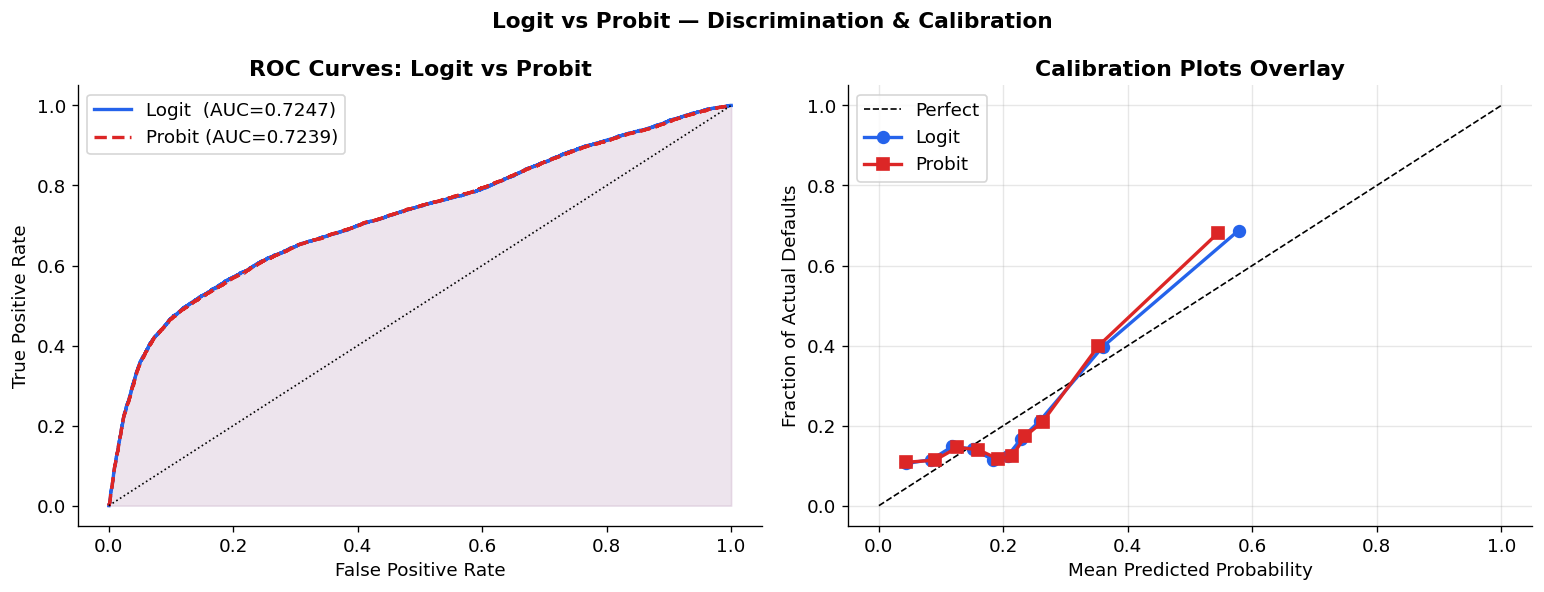

In [48]:
# ── Overlay ROC Curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(fpr_l, tpr_l, color=PALETTE['logit'],  lw=2, label=f'Logit  (AUC={auc_l:.4f})')
ax.plot(fpr_p, tpr_p, color=PALETTE['probit'], lw=2, linestyle='--', label=f'Probit (AUC={auc_p:.4f})')
ax.plot([0,1],[0,1], 'k:', lw=1)
ax.fill_between(fpr_l, tpr_l, alpha=0.07, color=PALETTE['logit'])
ax.fill_between(fpr_p, tpr_p, alpha=0.07, color=PALETTE['probit'])
ax.set_title('ROC Curves: Logit vs Probit', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend()

# ── Calibration overlay ───────────────────────────────────────────────────────
ax2 = axes[1]
fop_l, mpv_l = calibration_curve(y, df_model['prob_logit'],  n_bins=10, strategy='quantile')
fop_p, mpv_p = calibration_curve(y, df_model['prob_probit'], n_bins=10, strategy='quantile')
ax2.plot([0,1],[0,1], 'k--', lw=1, label='Perfect')
ax2.plot(mpv_l, fop_l, marker='o', color=PALETTE['logit'],  lw=2, ms=7, label='Logit')
ax2.plot(mpv_p, fop_p, marker='s', color=PALETTE['probit'], lw=2, ms=7, label='Probit')
ax2.set_title('Calibration Plots Overlay', fontweight='bold')
ax2.set_xlabel('Mean Predicted Probability')
ax2.set_ylabel('Fraction of Actual Defaults')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Logit vs Probit — Discrimination & Calibration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_calib_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


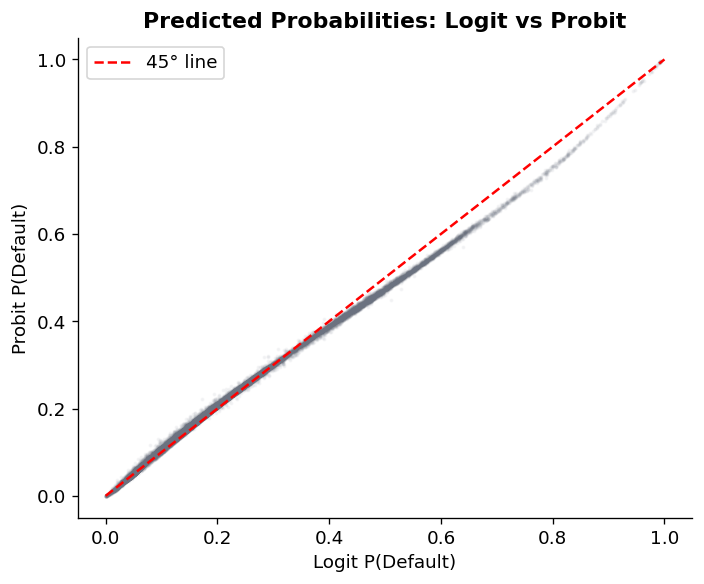

Correlation between Logit and Probit predictions: 0.998524


In [50]:
# ── Scatter: Predicted probabilities from both models ────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_model['prob_logit'], df_model['prob_probit'],
           alpha=0.05, s=2, color=PALETTE['neutral'])
ax.plot([0,1],[0,1], 'r--', lw=1.5, label='45° line')
ax.set_title('Predicted Probabilities: Logit vs Probit', fontweight='bold')
ax.set_xlabel('Logit P(Default)')
ax.set_ylabel('Probit P(Default)')
ax.legend()
plt.tight_layout()
plt.savefig('pred_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

corr = df_model[['prob_logit','prob_probit']].corr().iloc[0,1]
print(f"Correlation between Logit and Probit predictions: {corr:.6f}")

In [51]:
# ── Summary Metrics Table ─────────────────────────────────────────────────────
gini_l = 2 * auc_l - 1
gini_p = 2 * auc_p - 1

summary = pd.DataFrame({
    'Metric': ['Log-Likelihood', 'AIC', 'BIC',
               'McFadden R²', 'AUC', 'Gini', 'KS Statistic', 'Brier Score'],
    'Logit': [
        round(logit_result.llf, 2), round(logit_result.aic, 2), round(logit_result.bic, 2),
        round(logit_result.prsquared, 4), round(auc_l, 4), round(gini_l, 4),
        round(ks_logit, 4), round(brier_l, 4)
    ],
    'Probit': [
        round(probit_result.llf, 2), round(probit_result.aic, 2), round(probit_result.bic, 2),
        round(probit_result.prsquared, 4), round(auc_p, 4), round(gini_p, 4),
        round(ks_probit, 4), round(brier_p, 4)
    ]
})
print(summary.to_string(index=False))


        Metric       Logit      Probit
Log-Likelihood -13938.6900 -14038.9100
           AIC  27921.3800  28121.8100
           BIC  28104.1700  28304.6100
   McFadden R²      0.1207      0.1144
           AUC      0.7247      0.7239
          Gini      0.4494      0.4478
  KS Statistic      0.3754      0.3732
   Brier Score      0.1447      0.1461


> **Interpretation guide:**  
> - Higher Log-Likelihood (less negative), lower AIC/BIC → better fit  
> - Higher McFadden R², AUC, Gini, KS → better discrimination  
> - Lower Brier Score → better probability calibration  
>  
> Logit and Probit typically agree very closely on all metrics. The preferred model  
> is usually Logit due to the direct interpretability of coefficients as log-odds.


## 9. Credit Scorecard Transformation (Logit → Integer Score)

**Standard scaling convention:**  
- **PDO (Points to Double Odds) = 20** — score drops 20 points when default odds double  
- **Base score = 600** at base odds of 50:1  

Score = A − B × ln(odds),  where B = PDO/ln(2), A = base_score + B×ln(base_odds)


In [53]:
PDO, base_score, base_odds = 20, 600, 50

B = PDO / np.log(2)
A = base_score + B * np.log(base_odds)
print(f"Scaling constants: A = {A:.2f},  B = {B:.2f}")

df_model['odds']         = df_model['prob_logit'] / (1 - df_model['prob_logit'])
df_model['credit_score'] = (A - B * np.log(df_model['odds'])).round().astype(int)

print(f"Credit Score — Summary:")
print(df_model['credit_score'].describe().round(1))


Scaling constants: A = 712.88,  B = 28.85
Credit Score — Summary:
count    30000.0
mean       755.2
std         28.7
min        566.0
25%        744.0
50%        754.0
75%        771.0
max       1494.0
Name: credit_score, dtype: float64


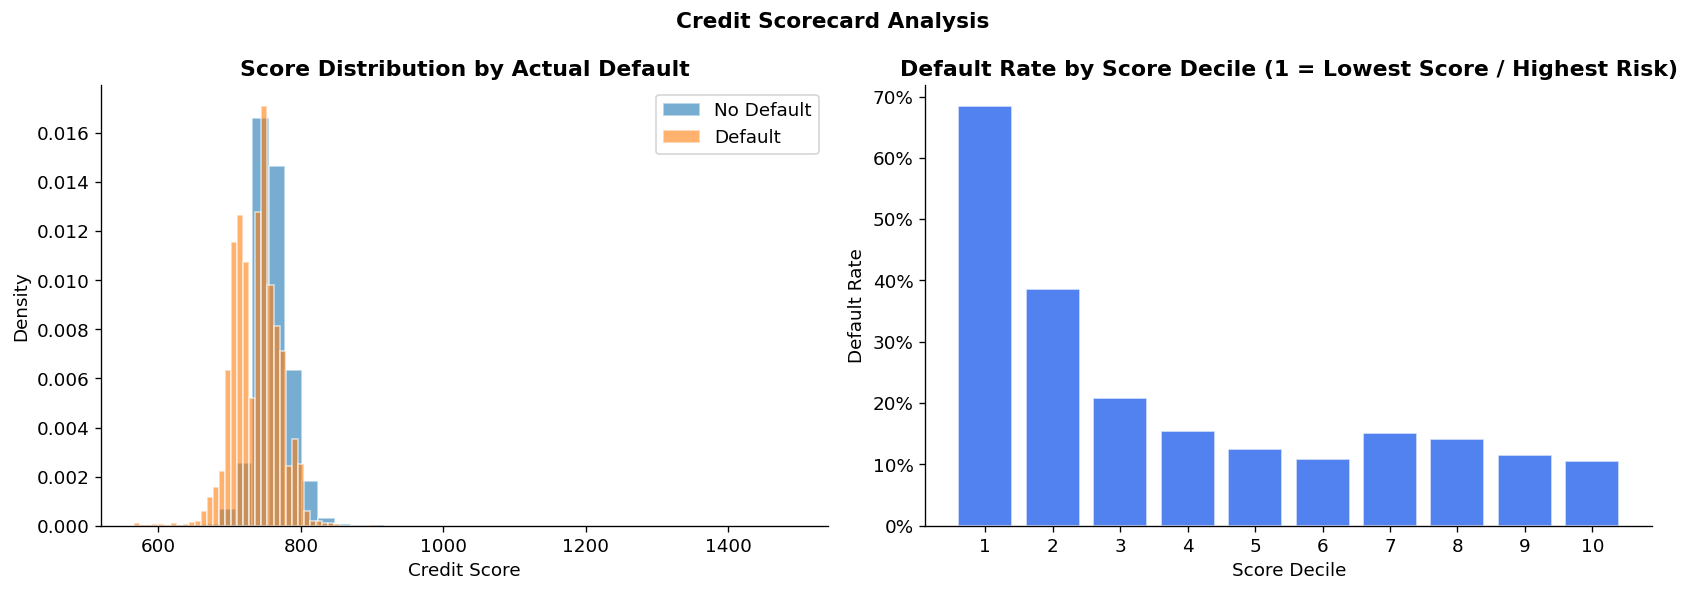

In [55]:
# ── Score distribution by default ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overlapping histogram
for val, label in [(0, 'No Default'), (1, 'Default')]:
    axes[0].hist(df_model.loc[df_model['DEFAULT']==val, 'credit_score'],
                 bins=40, alpha=0.6, density=True, edgecolor='white', label=label)
axes[0].set_title('Score Distribution by Actual Default', fontweight='bold')
axes[0].set_xlabel('Credit Score'); axes[0].set_ylabel('Density')
axes[0].legend()

# Right: default rate by decile
df_model['score_decile'] = pd.qcut(df_model['credit_score'], 10, labels=False)
rate_by_decile = df_model.groupby('score_decile')['DEFAULT'].mean()
axes[1].bar(rate_by_decile.index + 1, rate_by_decile.values,
            color=PALETTE['logit'], alpha=0.8, edgecolor='white')
axes[1].set_title('Default Rate by Score Decile (1 = Lowest Score / Highest Risk)', fontweight='bold')
axes[1].set_xlabel('Score Decile'); axes[1].set_ylabel('Default Rate')
axes[1].set_xticks(range(1, 11))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Credit Scorecard Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scorecard.png', dpi=150, bbox_inches='tight')
plt.show()
